In [7]:
import pandas as pd
import collections
import plotnine as p9
import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import calcutta

In [4]:
datadir = Path("/gpfs/commons/groups/knowles_lab/data/parse/original_SPLITseq_GSE110823/kallisto_output/merged/")
indexdir = Path("/gpfs/commons/groups/knowles_lab/index/kallisto/mus_musculus/")

count_file = datadir / "correct100.txt.gz"

transcripts, t2g_dic = calcutta.get_transcript_gene_map(
    datadir / "transcripts.txt",
    indexdir / "transcripts_to_genes.txt")

In [243]:
transcript_lengths_dic = calcutta.get_transcript_lengths(indexdir / "Mus_musculus.GRCm38.cdna.all.fa")

assert(all([ a==b for a,b in zip(transcript_lengths_dic.keys(), transcripts) ]) )

In [180]:
transcript_lengths = np.array(list(transcript_lengths_dic.values())) # chatGPT says fragment size is 300 lol

In [8]:
ec_map = calcutta.read_ec(datadir / "matrix.ec")

Check transcript count is consistent

In [183]:
len(transcripts)

118489

In [184]:
max(ec_reverse.keys())

118488

Check that number of EC is conistent

In [185]:
max(ec_map.keys()) 

533724

In [6]:
freq = calcutta.count_ECs_per_umi(count_file)
sum_freq = sum(freq.values())
x = range(1,31)
dat = pd.DataFrame({"x":x, "freq":[freq[i]/sum_freq for i in x]})
p9.ggplot(dat, p9.aes("x","freq",label="freq")) + p9.geom_text(format_string="{:.2g}") + p9.scale_y_log10() + p9.xlab("ECs per UMI")

KeyboardInterrupt: 

In [196]:
dat.head()

,x,freq
0,0,0.023171
1,1,0.808762
2,2,0.054550
3,3,0.024301
4,4,0.013504


4% of (BC,UMI) pairs have more than one EC. Will this still be the case for the full dataset? Depends how BCs are split across fastqs maybe? Also this is on the corrected data. Conclusion: yes it is. 

In [10]:
freq_transcript = calcutta.count_transcripts_per_umi(count_file, ec_map)

TypeError: 'int' object is not subscriptable

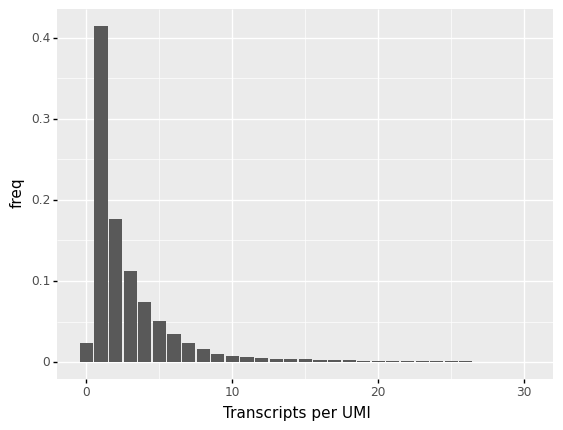

<ggplot: (8752505596808)>

In [191]:
sum_freq = sum(freq_transcript.values())
x = range(0,31)
dat = pd.DataFrame({"x":x, "freq":[freq_transcript[i]/sum_freq for i in x]})
p9.ggplot(dat, p9.aes("x","freq",label="freq")) + p9.geom_col() + p9.xlab("Transcripts per UMI")

This is actually surprising to me that 42% of UMIs map to a single transcript, but I suppose that is good! 1.4% of UMIs map to an inconsistent set of transcripts. 

In [192]:
freq_genes = calcutta.count_genes_per_umi(count_file)

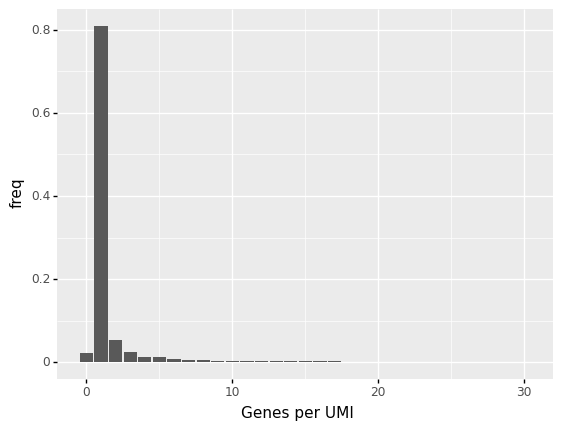

<ggplot: (8752429422026)>

In [193]:
sum_freq = sum(freq_genes.values())
x = range(0,31)
dat = pd.DataFrame({"x":x, "freq":[freq_genes[i]/sum_freq for i in x]})
p9.ggplot(dat, p9.aes("x","freq",label="freq")) + p9.geom_col() + p9.xlab("Genes per UMI")

In [194]:
dat.head()

,x,freq
0,0,0.023171
1,1,0.808762
2,2,0.054550
3,3,0.024301
4,4,0.013504


So over ~82% of UMIs align to a single gene at least. 

In [ ]:
import calcutta
cell_ec = calcutta.collapse_umis_per_cell(count_file, ec_map)

In [199]:
cell_depth = {bc : sum(g.values()) for bc,g in cell_ec.items() }

115.0

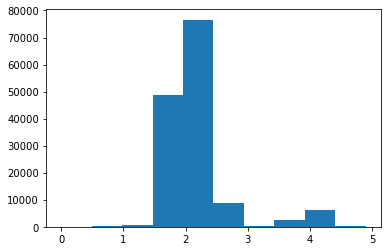

In [200]:
cell_depth_np = np.array(list(cell_depth.values()))

plt.hist(np.log10(cell_depth_np)) # 50-100 is range
np.median(cell_depth_np) # 1?! lol. Maybe do need to do correction? 

(144454,)

Filter for cells with >=10 UMIs. 

In [ ]:
# 600k without correction. Still a lot more than the 150k reported by the SPLIT-seq paper. 

In [202]:
my_ecs = set().union( *[g.keys() for bc,g in cell_ec.items()] )
len(my_ecs) # 418895, surprised still so many. 

418041

In [203]:
all_kallisto_ecs = { frozenset(g) for g in ec_map.values() } 
len(all_kallisto_ecs) # ~0.5M of these

533725

In [204]:
len(my_ecs.intersection(all_kallisto_ecs)) / len(my_ecs)

0.9260981578361931

About 7.5% of my ECs are not in the kallisto ECs (i.e. formed by intersection of kallisto ECs).

## Convert cell_ec into a sparse matrix

Sort by length then lowest id to put unambiguous ECs first

In [209]:
sorted_ecs, ec_id_map, sorted_BCs, indices, umi_counts = calcutta.cell_ec_to_sparse(cell_ec)

In [213]:
len(sorted_BCs)

144454

In [ ]:
# np.save("uncorrected.npy", a, allow_pickle=False)
# np.savez("test.npz", a, allow_pickle=False) # this doesn't save any space

This is slow (5min?)! but does reduce from 2.3G to 0.3G! 

In [214]:
np.savez_compressed(
    "corrected.compressed.npz", 
    np.concatenate([indices, umi_counts[None,:]]), 
    allow_pickle=False) 

In [215]:
with open("corrected.ec","w") as f: 
    for g in sorted_ecs: 
        f.write(",".join([str(h) for h in g]) + "\n")